# Flip-Angle-Reihe – Gaußpuls auf Wasserpool
Simuliert Gaußpulse mit Flipwinkeln von 0° bis 180° und stellt transversale und longitudinale Magnetisierung gemeinsam dar.

In [27]:
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import pypulseq as pp
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from bmc.simulate import simulate
from bmc.utils.seq.write import write_seq
from bmc.utils.results import save_simulation, load_simulation

## Einstellungen

In [28]:
# ── Pfade ──────────────────────────────────────────────────────────────────
wdir        = Path().resolve()
config_path = wdir / 'sim_lib' / 'config_1pool.yaml'
seq_tmp_dir = wdir / 'seq_lib' / 'flip_angle_series'
seq_tmp_dir.mkdir(parents=True, exist_ok=True)

# Ausgabe-Ordner für alle Simulationen dieser Reihe
series_label = f"flip_angle_series_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
series_dir   = wdir / 'results' / 'simulations' / series_label
series_dir.mkdir(parents=True, exist_ok=True)

# ── Flipwinkel-Reihe: 10° bis 90° in 20°-Schritten ────────────────────────
flip_angles_deg = np.arange(10, 91, 20)   # 10°, 30°, 50°, 70°, 90°  (5 Werte)

# ── Sequenz-Parameter (identisch zu 90.ipynb) ──────────────────────────────
sys = pp.Opts(
    max_grad=500,
    grad_unit='mT/m',
    max_slew=1e9,
    slew_unit='T/m/s',
    rf_ringdown_time=0,
    rf_dead_time=0,
    rf_raster_time=1e-6,
    gamma=42576400,
    grad_raster_time=1e-6,
)

B0        = 17        # [T]
t_pulse   = 2e-3      # [s]
adc_time  = 50e-3     # [s]

GAMMA_HZ  = sys.gamma * 1e-6
freq_hz   = B0 * GAMMA_HZ

# ── Isochromaten ───────────────────────────────────────────────────────────
low, high, n_iso = -1e-3, 1e-3, 100
z_pos = np.linspace(low, high, n_iso)
z_pos = torch.tensor(z_pos)
z_pos = torch.cat((z_pos, torch.tensor([0.0])))
z_pos = torch.sort(z_pos).values

print(f"Flipwinkel: {flip_angles_deg}")
print(f"Ergebnisse werden gespeichert in: {series_dir}")


Flipwinkel: [10 30 50 70 90]
Ergebnisse werden gespeichert in: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533


## Sequenzen erstellen, simulieren und speichern

In [29]:
result_dirs = {}   # fa_deg -> Path

for fa_deg in flip_angles_deg:
    print(f"\n── {fa_deg}° ──")

    # ── Sequenz erzeugen ──────────────────────────────────────────────────
    defs = {
        'a':          float(fa_deg),
        'b0':         B0,
        'm0_offset':  0,
        'n_ETM':      1,
        'seq_id_string': f'fa_{int(fa_deg):03d}',
    }
    defs['offsets_ppm'] = np.array([defs['m0_offset']])
    defs['num_meas']    = int(defs['offsets_ppm'].size)
    defs['freq']        = freq_hz

    seq = pp.Sequence()

    if fa_deg == 0:
        # Kein RF-Puls – nur Delay in Puls-Länge + Delay + ADC
        seq.add_block(pp.make_delay(t_pulse))
    else:
        rf = pp.make_gauss_pulse(
            flip_angle=np.radians(fa_deg),
            system=sys,
            duration=t_pulse,
            center_pos=0.5,
            freq_offset=0.0,
            phase_offset=0.0,
            return_gz=False,
        )
        rf.freq_offset = 0.0
        seq.add_block(rf)

    seq.add_block(pp.make_delay(10e-3))
    seq.add_block(pp.make_adc(num_samples=1, duration=1e-3))

    seq_file = seq_tmp_dir / f"fa_{int(fa_deg):03d}.seq"
    write_seq(seq=seq, seq_defs=defs, filename=seq_file, author='DANIEL MIKSCH', use_matlab_names=True)

    # ── Simulation ────────────────────────────────────────────────────────
    sim = simulate(
        config_file=config_path,
        seq_file=seq_file,
        z_positions=z_pos,
        adc_time=adc_time,
        iso_select=None,       # iso_select nur für Plot relevant (show_plot=False)
        return_zmag=False,
        show_plot=False,
        webhook=False,
        plt_range=[0, 4],
        n_backlog='ALL',
    )

    # ── Speichern ─────────────────────────────────────────────────────────
    out = save_simulation(sim, label=f"fa_{int(fa_deg):03d}", results_root=series_dir)
    result_dirs[float(fa_deg)] = out
    print(f"   gespeichert: {out.name}")

print(f"\n✓ Alle {len(flip_angles_deg)} Simulationen gespeichert in:\n  {series_dir}")



── 10° ──


BMCTool simulation: 100%|██████████| 3/3 [00:00<00:00, 12.14it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533/fa_010_20260427_192533
   gespeichert: fa_010_20260427_192533

── 30° ──


BMCTool simulation: 100%|██████████| 3/3 [00:00<00:00, 12.75it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533/fa_030_20260427_192533
   gespeichert: fa_030_20260427_192533

── 50° ──


...

[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533/fa_050_20260427_192534
   gespeichert: fa_050_20260427_192534

── 70° ──


BMCTool simulation: 100%|██████████| 3/3 [00:00<00:00, 13.04it/s]


[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533/fa_070_20260427_192534
   gespeichert: fa_070_20260427_192534

── 90° ──


BMCTool simulation: 100%|██████████| 3/3 [00:00<00:00, 12.90it/s]

[results] Saved simulation to: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533/fa_090_20260427_192534
   gespeichert: fa_090_20260427_192534

✓ Alle 5 Simulationen gespeichert in:
  /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533


## Ergebnisse laden und gemeinsam plotten

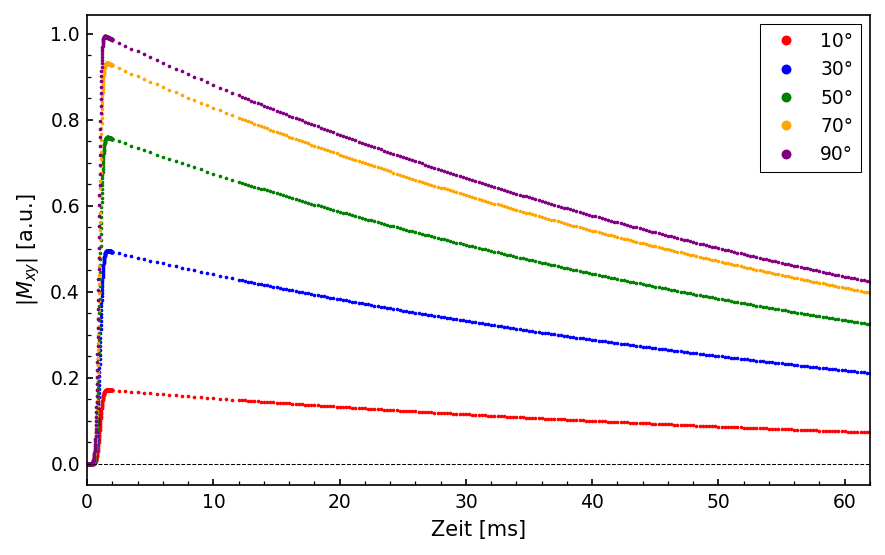

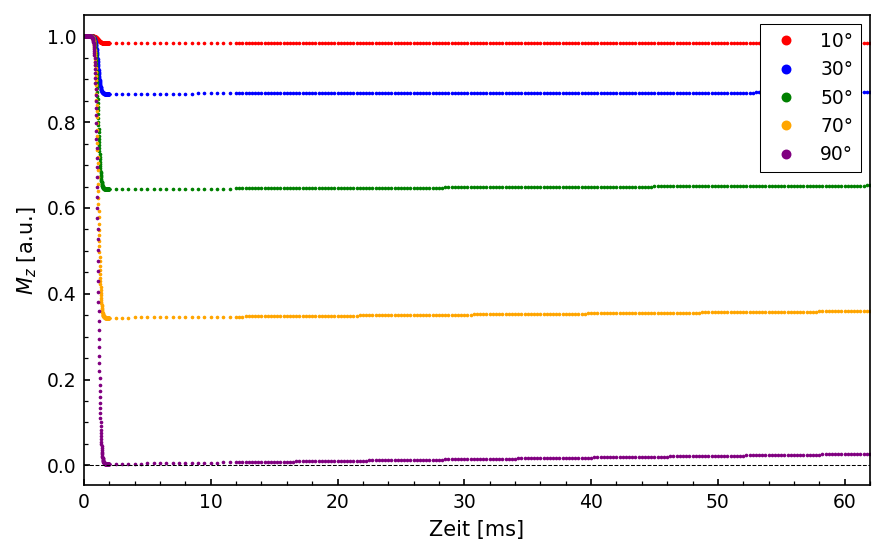


Plots gespeichert in: /Users/danielmiksch/JupyterLab/optim/results/simulations/flip_angle_series_20260427_192533


In [ ]:
import matplotlib as mpl

# ── Plot-Stil ──────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'text.usetex':         False,
    'font.family':         'sans-serif',
    'font.size':           10,
    'axes.labelsize':      10,
    'axes.titlesize':      11,
    'legend.fontsize':     9,
    'xtick.labelsize':     9,
    'ytick.labelsize':     9,
    'axes.linewidth':      0.8,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.size':    3,
    'ytick.major.size':    3,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'lines.linewidth':     1.2,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# ── Farben ─────────────────────────────────────────────────────────────────
COLORS = ['red', 'blue', 'green', 'orange', 'purple']

# ── Daten laden ────────────────────────────────────────────────────────────
fa_list     = sorted(result_dirs.keys())
n_fa        = len(fa_list)
colors      = COLORS[:n_fa]
mz_loc      = 2
MARKER_SIZE = 1.5

trans_data = {}
long_data  = {}
t_max      = 0.0

for fa_deg in fa_list:
    loaded       = load_simulation(result_dirs[fa_deg])
    m_out        = loaded['m_out']
    t            = loaded['t']
    n_iso_loaded = m_out.shape[0]

    m_x = np.sum(m_out[:, 0, :], axis=0) / n_iso_loaded
    m_y = np.sum(m_out[:, 1, :], axis=0) / n_iso_loaded
    m_z = np.sum(m_out[:, mz_loc, :], axis=0) / n_iso_loaded

    t_ms = t * 1e3
    mask = t_ms >= 0
    t_ms = t_ms[mask]
    trans_data[fa_deg] = (t_ms, np.abs(m_x + 1j * m_y)[mask])
    long_data[fa_deg]  = (t_ms, m_z[mask])
    t_max = max(t_max, t_ms[-1])

# ── Plot 1: Transversale Magnetisierung ────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 3.8))

for idx, fa_deg in enumerate(fa_list):
    t_ms, signal = trans_data[fa_deg]
    ax1.plot(t_ms, signal, '.', color=colors[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'{int(fa_deg)}\u00b0')

ax1.set_xlabel('Zeit [ms]')
ax1.set_ylabel('$|M_{xy}|$ [a.u.]')
ax1.set_xlim(0, t_max)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.grid(True, linewidth=0.4, color='gray', alpha=0.3)

leg1 = ax1.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=5)
leg1.get_frame().set_linewidth(0.5)

fig1.tight_layout()
fig1.savefig(series_dir / 'transverse_magnetization.pdf')
fig1.savefig(series_dir / 'transverse_magnetization.png')
plt.show()

# ── Plot 2: Longitudinale Magnetisierung ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 3.8))

for idx, fa_deg in enumerate(fa_list):
    t_ms, signal = long_data[fa_deg]
    ax2.plot(t_ms, signal, '.', color=colors[idx], markersize=MARKER_SIZE,
             linestyle='none', label=f'{int(fa_deg)}\u00b0')

ax2.set_xlabel('Zeit [ms]')
ax2.set_ylabel('$M_z$ [a.u.]')
ax2.set_xlim(0, t_max)
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.grid(True, linewidth=0.4, color='gray', alpha=0.3)

leg2 = ax2.legend(loc='upper right', frameon=True, fancybox=False,
                  framealpha=1.0, edgecolor='black', markerscale=5)
leg2.get_frame().set_linewidth(0.5)

fig2.tight_layout()
fig2.savefig(series_dir / 'longitudinal_magnetization.pdf')
fig2.savefig(series_dir / 'longitudinal_magnetization.png')
plt.show()

print(f"\nPlots gespeichert in: {series_dir}")
